# Intrinsics Thermal Correlations (v1)

**Author:** Aaron Roodman  
**Date Created:** 2026-04-06  
**Last Modified:** 2026-04-06  
**Status:** Draft  
**Keywords:** intrinsics, thermal, Double Zernike, PCA, correlations  

## Description

Investigate correlations between Double Zernike (DZ) fit coefficients and thermal
variables from the EFD. DZ coefficients describe how each pupil-plane Zernike
aberration varies across the focal plane; thermal environment changes drive
mirror figure and structure deformations that should appear as DZ coefficient
variations.

Key functionality:
1. Scatter plots of selected DZ coefficients vs each thermal variable
2. PCA-based multivariate analysis of thermal–DZ correlations
3. Combined PDF output of all plots

**Output:** PDF in same subdirectory as input table  
**Based on:** intrinsics_plots.ipynb (DZ fits), intrinsics_addthermal.ipynb (thermal augmentation)

## Change Log

| Date | Author | Description |
|------|--------|-------------|
| 2026-04-06 | Aaron Roodman | Initial version |

## Table of Contents

1. [Parameters](#params)
2. [Setup & Imports](#setup)
3. [Data Access](#data)
4. [Scatter Plots: DZ Coefficients vs Thermal Variables](#scatter)
5. [Multivariate Analysis: PCA Regression](#pca)
6. [Output](#output)

<a id='params'></a>
## Parameters

In [1]:
# ============================================================
# Parameters — All configurable values collected here
# ============================================================

input_dir = "output/fam_danish_bin1_OCS_wep_v16_8_0_dviz_v3_5_0_20260315_20260317"
input_file = "fam_danish_bin1_intrinsic_fits_thermal_wep_v16_8_0_dviz_v3_5_0_20260315_20260317.parquet"

output_dir = input_dir
output_pdf = f"{output_dir}/intrinsics_thermal_correlations.pdf"

# Double Zernike coefficient column prefix (from intrinsics_plots fit)
dz_prefix = "z1toz6"

# DZ terms to plot: (k, j) where k = focal-plane Zernike Noll index,
# j = pupil-plane Zernike Noll index.
# Column name: {dz_prefix}_z{j}_c{k}
dz_terms_to_plot = [
    (5, 5),   # focal astig45 amplitude of pupil astig45
    (6, 6),   # focal astig0 amplitude of pupil astig0
    (4, 4),   # focal defocus amplitude of pupil defocus
    (5, 10),  # focal astig45 amplitude of pupil trefoil
    (6, 9),   # focal astig0 amplitude of pupil trefoil
]

# Thermal variables
thermal_vars = [
    "cam_air_temp",
    "m2_air_temp",
    "m1m3_air_temp",
    "outside_temp",
    "m2_delta_t",
    "cam_m1m3_delta_t",
    "dome_delta_t",
    "x_gradient",
    "y_gradient",
    "z_gradient",
    "radial_gradient",
    "tma_truss_temp_pxpy",
    "tma_truss_temp_mxmy",
]

# Quality cuts
max_coeff_um = 2.0  # reject visits with any DZ coefficient > this (microns)

# Number of PCA components to retain for regression
n_pca_components = 5

<a id='setup'></a>
## Setup & Imports

In [2]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, str(Path.cwd().parent))
from common.utils import setup_plotting

setup_plotting()

<a id='data'></a>
## Data Access

In [3]:
input_path = Path(input_dir) / input_file
df = pd.read_parquet(input_path)
print(f"Loaded {len(df)} rows x {len(df.columns)} columns from {input_path.name}")
print(f"day_obs values: {sorted(df['day_obs'].unique())}")

Loaded 178 rows x 451 columns from fam_danish_bin1_intrinsic_fits_thermal_wep_v16_8_0_dviz_v3_5_0_20260315_20260317.parquet
day_obs values: [np.int64(20260315), np.int64(20260316), np.int64(20260317)]


In [4]:
# Quality cuts: remove bad fits and visits with large coefficients
n_before = len(df)

# 1. Use bad_fit flag if present (from intrinsics_plots)
bad_fit_col = f"{dz_prefix}_bad_fit"
if bad_fit_col in df.columns:
    n_bad = df[bad_fit_col].sum()
    df = df[~df[bad_fit_col]].copy()
    print(f"Removed {n_bad} visits flagged as {bad_fit_col}")
elif "bad_fit" in df.columns:
    n_bad = df["bad_fit"].sum()
    df = df[~df["bad_fit"]].copy()
    print(f"Removed {n_bad} visits flagged as bad_fit")
else:
    print("No bad_fit column found — skipping flag-based cut")

# 2. Remove visits where any DZ coefficient exceeds max_coeff_um
#    Check all coefficient columns matching the prefix
dz_coeff_cols = [c for c in df.columns
                 if c.startswith(f"{dz_prefix}_z") and "_c" in c
                 and not c.endswith("_err")]
print(f"Checking {len(dz_coeff_cols)} DZ coefficient columns for |coeff| > {max_coeff_um} µm")

outlier_mask = df[dz_coeff_cols].abs().gt(max_coeff_um).any(axis=1)
n_outlier = outlier_mask.sum()
if n_outlier > 0:
    bad_visits = df.loc[outlier_mask, ["day_obs", "seq_num"]].values
    df = df[~outlier_mask].copy()
    print(f"Removed {n_outlier} visits with |coeff| > {max_coeff_um} µm:")
    for dobs, snum in bad_visits:
        print(f"  day_obs={dobs}, seq_num={snum}")
else:
    print("No visits exceed coefficient threshold")

print(f"\nAfter quality cuts: {len(df)}/{n_before} visits remain")

Removed 1 visits flagged as z1toz6_bad_fit
Checking 126 DZ coefficient columns for |coeff| > 2.0 µm
No visits exceed coefficient threshold

After quality cuts: 177/178 visits remain


In [5]:
# Build list of available DZ coefficient columns and validate requested terms
def dz_col_name(k, j, prefix=dz_prefix):
    """Column name for DZ coefficient (k, j)."""
    return f"{prefix}_z{j}_c{k}"

available_dz = []
skipped_dz = []
for k, j in dz_terms_to_plot:
    col = dz_col_name(k, j)
    if col in df.columns:
        available_dz.append((k, j, col))
    else:
        skipped_dz.append((k, j, col))

print(f"Available DZ terms: {len(available_dz)}")
for k, j, col in available_dz:
    print(f"  (k={k}, j={j}) -> {col}")
if skipped_dz:
    print(f"\nSkipped (not in data): {len(skipped_dz)}")
    for k, j, col in skipped_dz:
        print(f"  (k={k}, j={j}) -> {col} NOT FOUND")

# Check thermal columns
print(f"\nThermal variables: {len(thermal_vars)}")
for tv in thermal_vars:
    n_valid = df[tv].notna().sum() if tv in df.columns else 0
    status = f"{n_valid}/{len(df)} valid" if tv in df.columns else "MISSING"
    print(f"  {tv}: {status}")

Available DZ terms: 5
  (k=5, j=5) -> z1toz6_z5_c5
  (k=6, j=6) -> z1toz6_z6_c6
  (k=4, j=4) -> z1toz6_z4_c4
  (k=5, j=10) -> z1toz6_z10_c5
  (k=6, j=9) -> z1toz6_z9_c6

Thermal variables: 13
  cam_air_temp: 177/177 valid
  m2_air_temp: 177/177 valid
  m1m3_air_temp: 177/177 valid
  outside_temp: 177/177 valid
  m2_delta_t: 177/177 valid
  cam_m1m3_delta_t: 177/177 valid
  dome_delta_t: 177/177 valid
  x_gradient: 175/177 valid
  y_gradient: 175/177 valid
  z_gradient: 175/177 valid
  radial_gradient: 175/177 valid
  tma_truss_temp_pxpy: 177/177 valid
  tma_truss_temp_mxmy: 177/177 valid


<a id='scatter'></a>
## Scatter Plots: DZ Coefficients vs Thermal Variables

For each DZ term (k, j), produce a page of scatter plots showing the coefficient
value vs each of the thermal variables. Each point is one visit. A linear
regression line and Pearson correlation coefficient are overlaid.

In [6]:
def scatter_page(df, dz_col, k, j, thermal_vars, ax_array):
    """Fill a grid of axes with scatter plots of dz_col vs thermal variables.

    Parameters
    ----------
    df : DataFrame
        Data table.
    dz_col : str
        Column name for the DZ coefficient.
    k, j : int
        Focal-plane and pupil-plane Zernike indices.
    thermal_vars : list of str
        Thermal variable column names.
    ax_array : ndarray of Axes
        Flattened array of axes to plot into.
    """
    for idx, tv in enumerate(thermal_vars):
        ax = ax_array[idx]
        mask = df[dz_col].notna() & df[tv].notna()
        x = df.loc[mask, tv].values
        y = df.loc[mask, dz_col].values

        ax.scatter(x, y, s=12, alpha=0.7, edgecolors='none')

        # Linear fit and correlation
        if len(x) > 2:
            coeffs = np.polyfit(x, y, 1)
            r = np.corrcoef(x, y)[0, 1]
            xfit = np.linspace(x.min(), x.max(), 50)
            ax.plot(xfit, np.polyval(coeffs, xfit), 'r-', lw=1.5, alpha=0.8)
            ax.text(0.05, 0.92, f'r = {r:.3f}', transform=ax.transAxes,
                    fontsize=9, va='top',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

        ax.set_xlabel(tv, fontsize=8)
        ax.set_ylabel(f'({k},{j}) [\u03bcm]', fontsize=8)
        ax.tick_params(labelsize=7)

    # Hide unused axes
    for idx in range(len(thermal_vars), len(ax_array)):
        ax_array[idx].set_visible(False)

/tmp/ipykernel_1860/1225799138.py:12: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


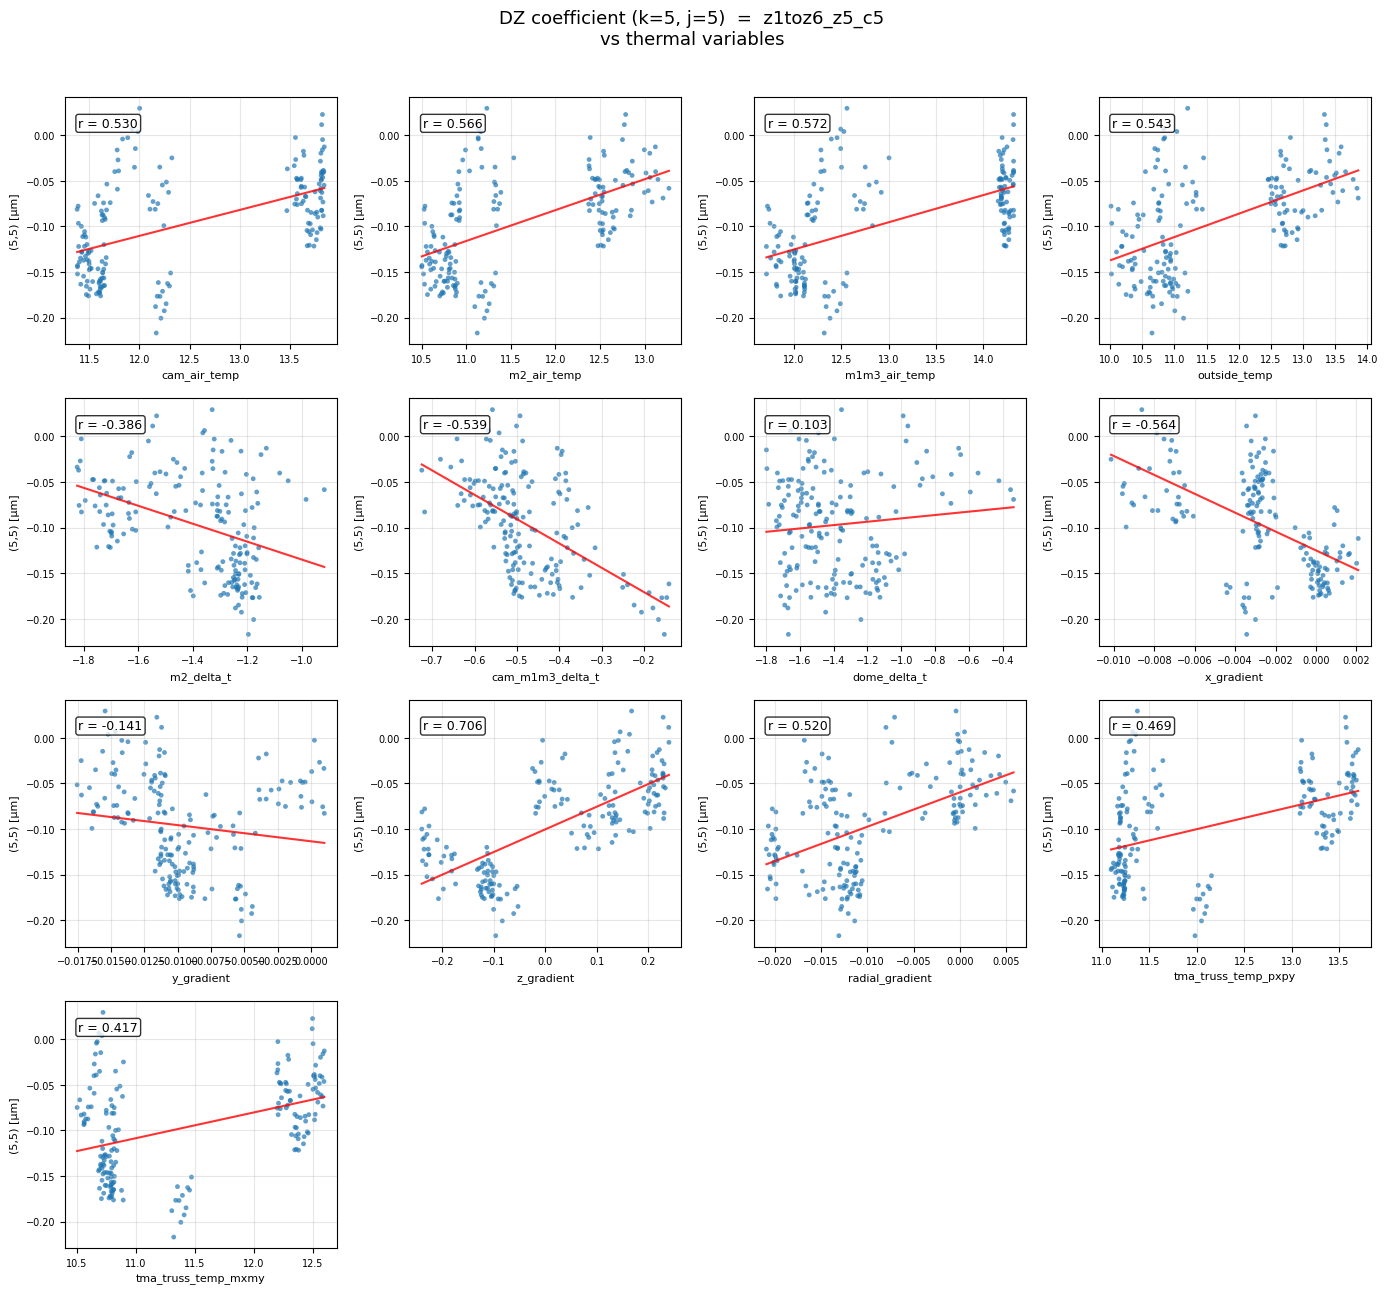

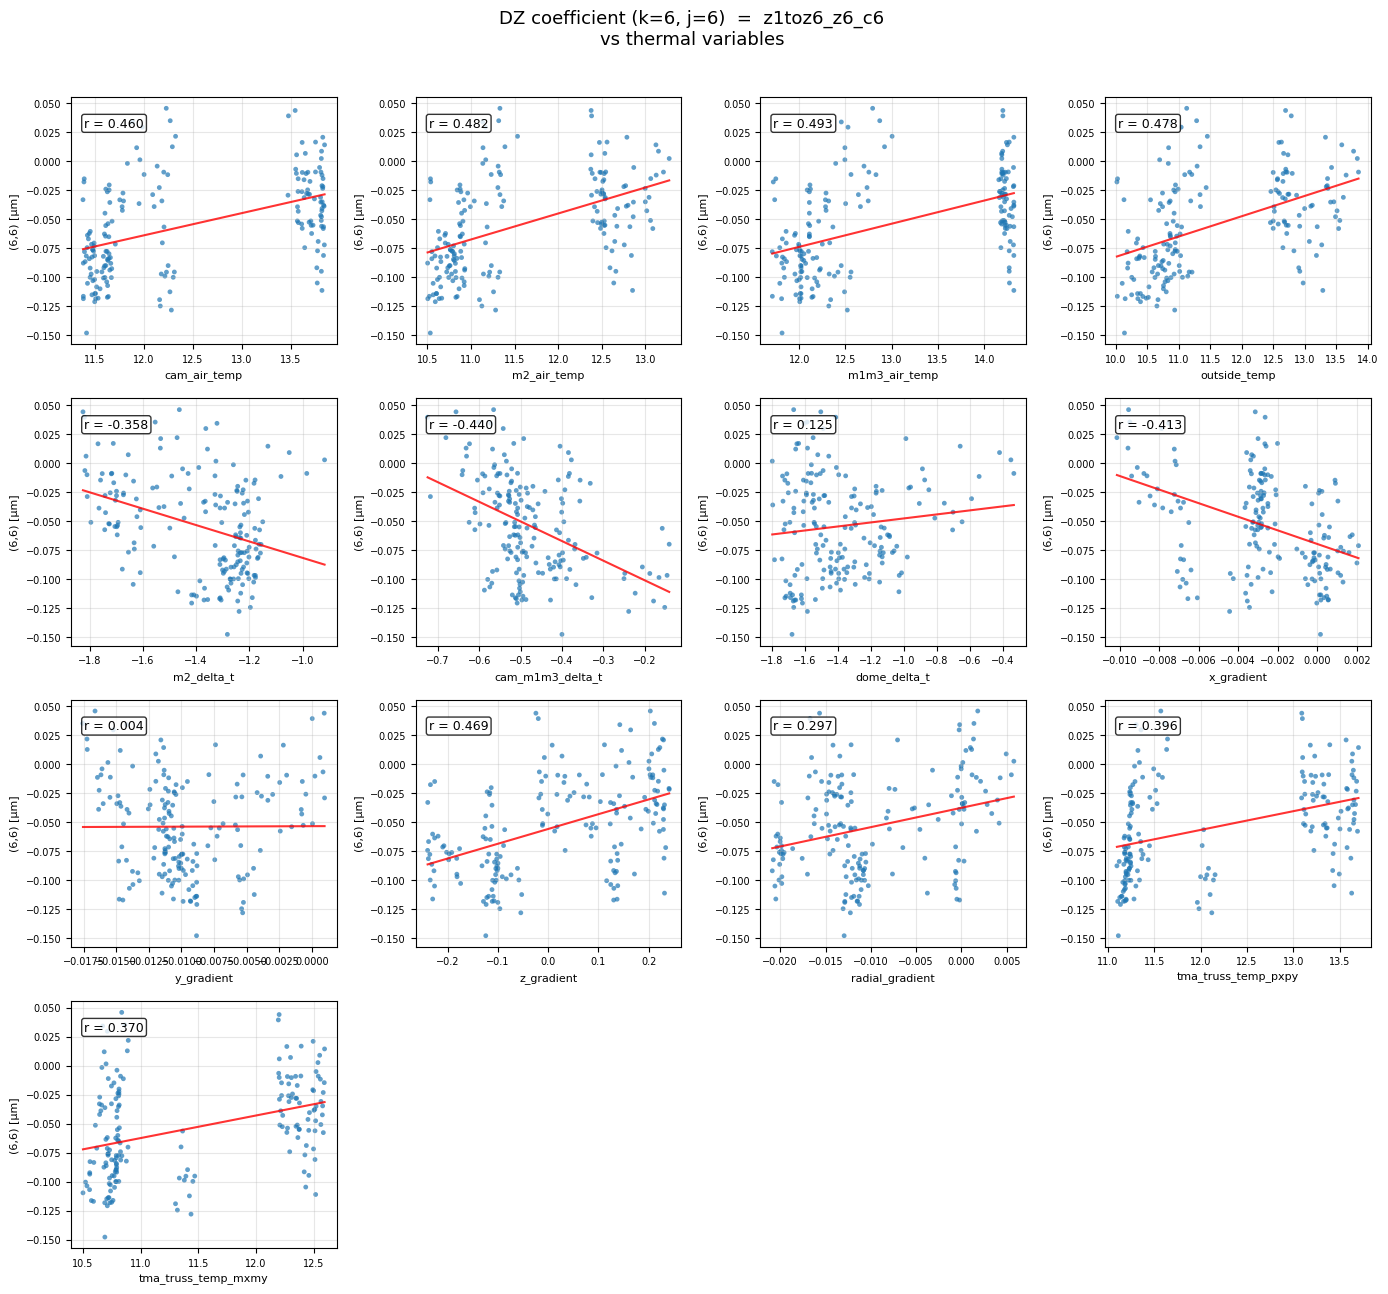

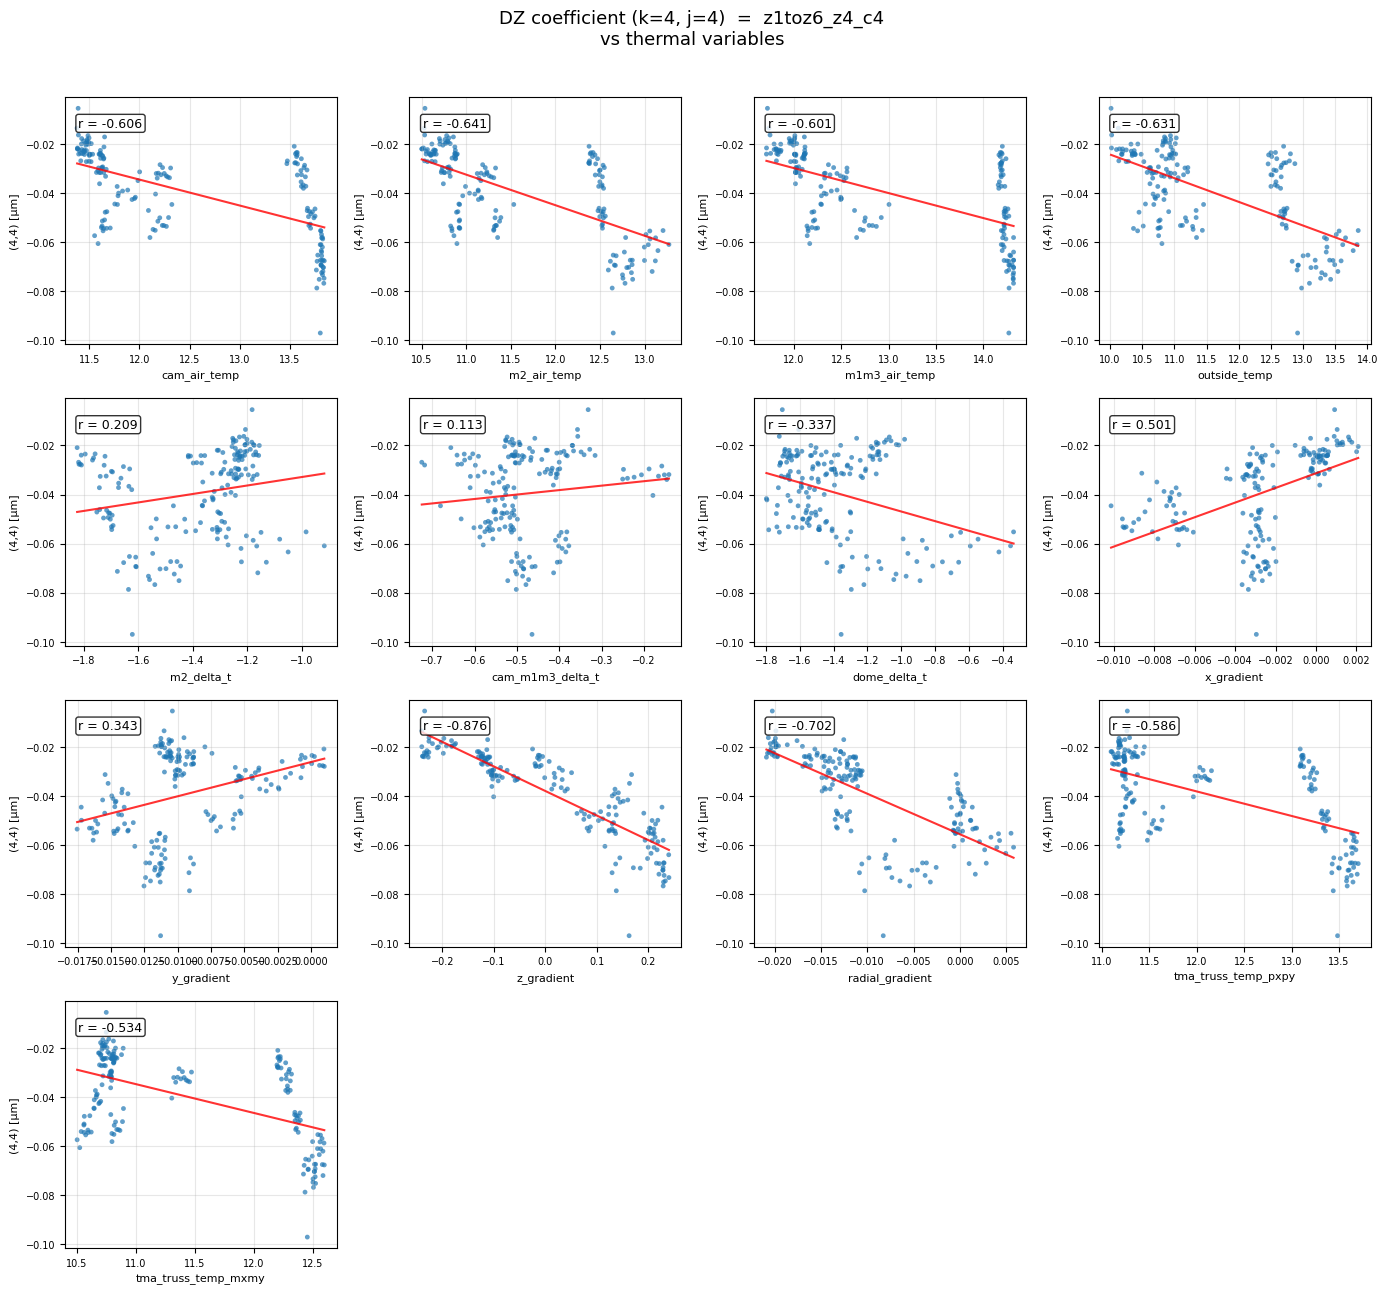

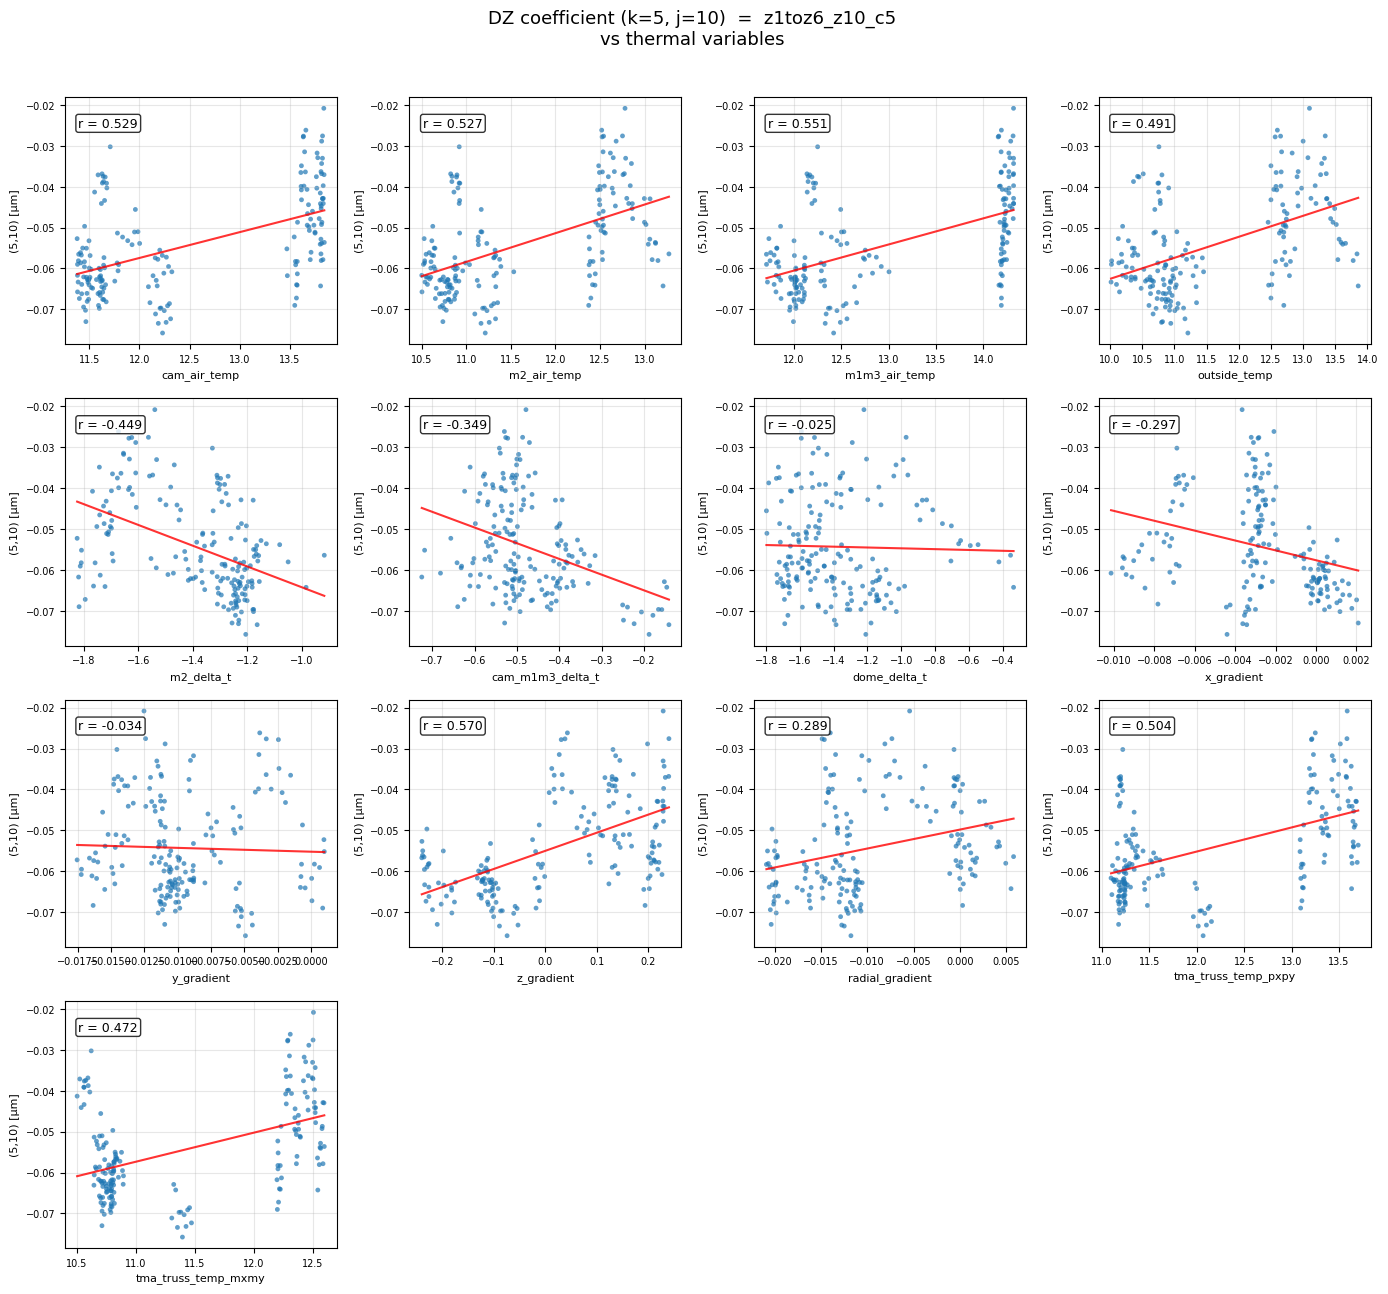

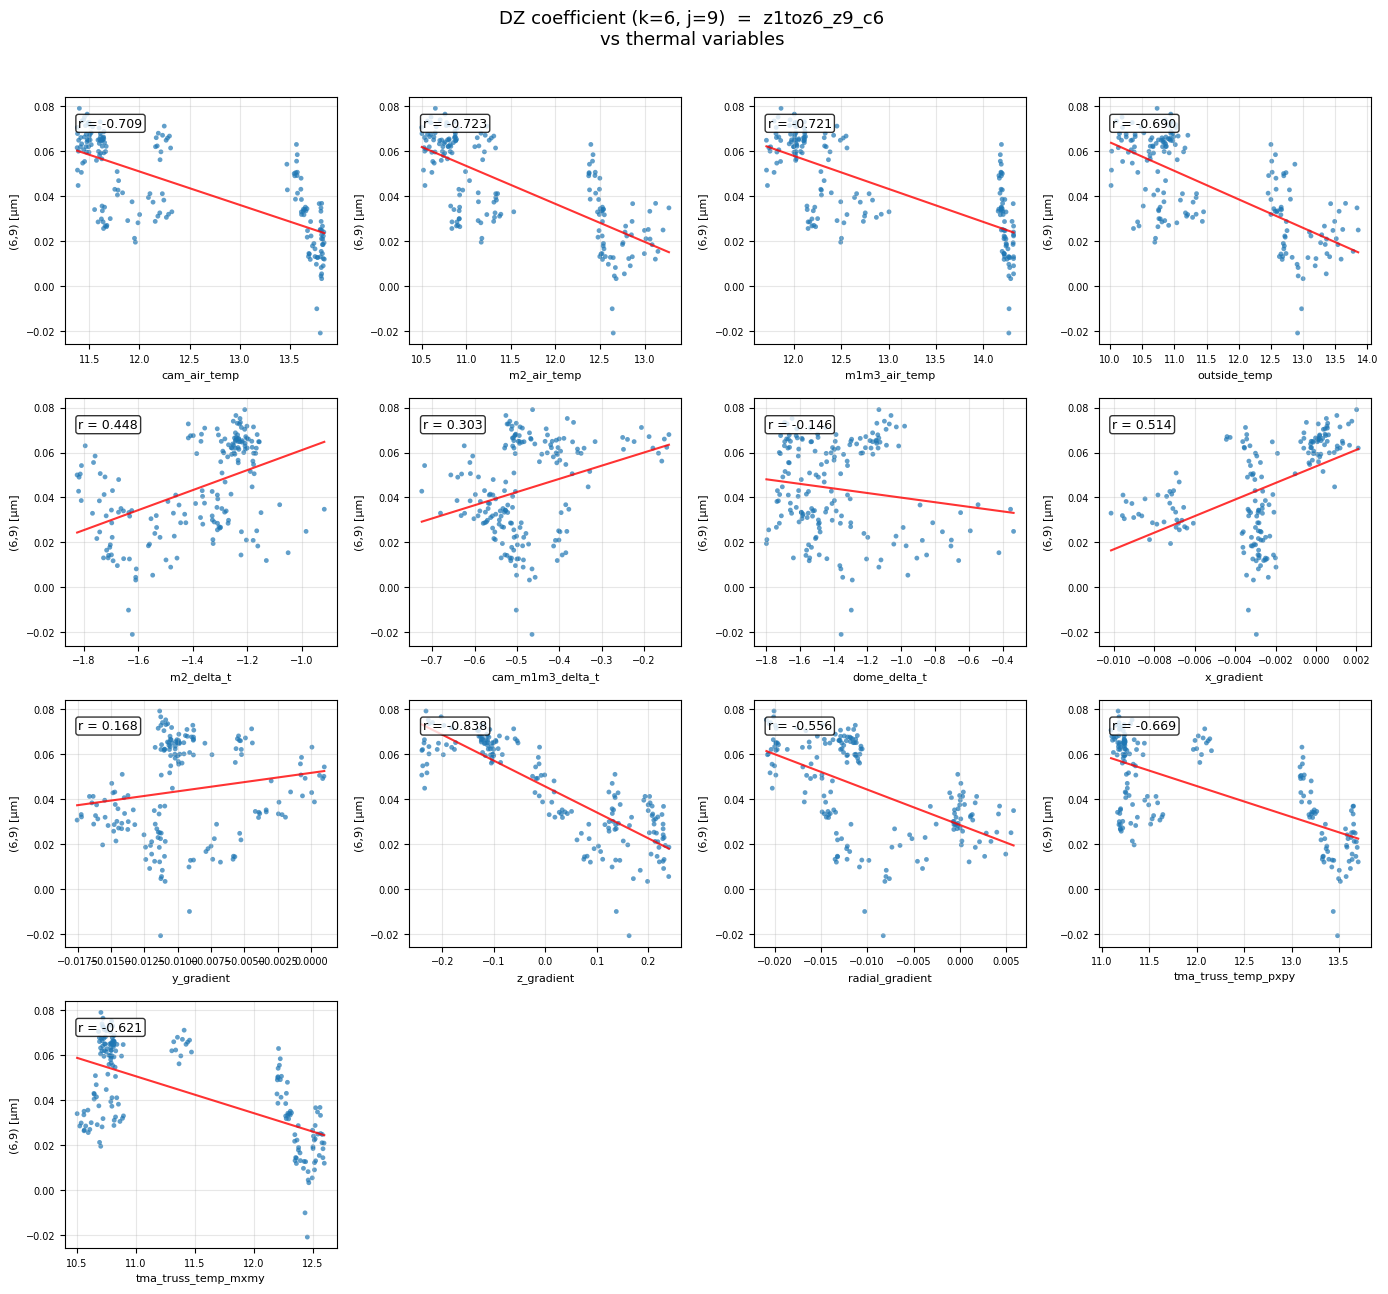

In [7]:
# Grid layout: enough subplots for all thermal variables
n_thermal = len(thermal_vars)
ncols = 4
nrows = int(np.ceil(n_thermal / ncols))

scatter_figs = []
for k, j, dz_col in available_dz:
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows))
    fig.suptitle(f'DZ coefficient (k={k}, j={j})  =  {dz_col}\nvs thermal variables',
                 fontsize=13, y=1.01)
    scatter_page(df, dz_col, k, j, thermal_vars, axes.ravel())
    fig.tight_layout()
    scatter_figs.append(fig)
    plt.show()

<a id='pca'></a>
## Multivariate Analysis: PCA Regression

With only ~178 visits and 13 thermal predictors, a train/test split would leave
very few samples for reliable validation. Instead we use PCA to reduce the
thermal variable space and then regress each DZ coefficient on the leading
principal components.

### Method

1. **Standardize** the thermal variables (zero mean, unit variance) so PCA is
   not dominated by variables with large absolute values (e.g. absolute
   temperatures vs delta-T quantities).
2. **PCA** on the standardized thermal matrix to obtain orthogonal components
   that capture the dominant modes of thermal variability.
3. **OLS regression** of each DZ coefficient on the first *N* principal
   components. Because the PCs are orthogonal, multicollinearity is eliminated
   and the regression is well-conditioned even with limited data.
4. Report the fraction of DZ variance explained (R\u00b2) and the loadings of
   original thermal variables onto each significant PC, so we can interpret
   which physical thermal modes drive each aberration.

This approach is equivalent to Principal Component Regression (PCR). It trades
a small amount of potential overfitting (no held-out test set) for the ability
to use all available data in a regime where N \u226b p is not satisfied.

In [8]:
# Prepare thermal matrix: drop rows with any NaN in thermal columns
thermal_df = df[thermal_vars].copy()
valid_mask = thermal_df.notna().all(axis=1)
print(f"Rows with all thermal variables valid: {valid_mask.sum()}/{len(df)}")

thermal_clean = thermal_df.loc[valid_mask].values

# Standardize
scaler = StandardScaler()
thermal_std = scaler.fit_transform(thermal_clean)

# PCA
pca = PCA(n_components=min(n_pca_components, thermal_std.shape[1]))
pc_scores = pca.fit_transform(thermal_std)

print(f"\nPCA on {thermal_std.shape[1]} thermal variables, {thermal_std.shape[0]} visits")
print(f"Components retained: {pca.n_components_}")
print(f"Explained variance ratio:")
cum_var = 0.0
for i, ev in enumerate(pca.explained_variance_ratio_):
    cum_var += ev
    print(f"  PC{i+1}: {ev:.3f}  (cumulative: {cum_var:.3f})")

Rows with all thermal variables valid: 175/177

PCA on 13 thermal variables, 175 visits
Components retained: 5
Explained variance ratio:
  PC1: 0.549  (cumulative: 0.549)
  PC2: 0.214  (cumulative: 0.763)
  PC3: 0.145  (cumulative: 0.909)
  PC4: 0.060  (cumulative: 0.968)
  PC5: 0.017  (cumulative: 0.986)


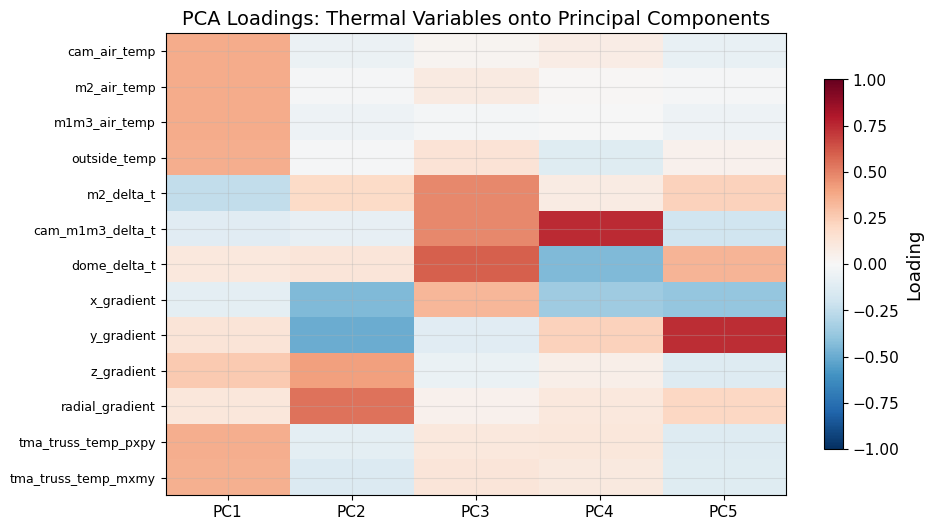

In [9]:
# Plot PCA loadings: which thermal variables contribute to each PC
loadings = pd.DataFrame(
    pca.components_.T,
    index=thermal_vars,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

fig_loadings, ax = plt.subplots(figsize=(10, 6), layout='none')
im = ax.imshow(loadings.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(pca.n_components_))
ax.set_xticklabels(loadings.columns)
ax.set_yticks(range(len(thermal_vars)))
ax.set_yticklabels(thermal_vars, fontsize=9)
ax.set_title('PCA Loadings: Thermal Variables onto Principal Components')
plt.colorbar(im, ax=ax, shrink=0.8, label='Loading')
plt.show()

(k=5, j=5)  R² = 0.625  R²_adj = 0.613  (n=175)


/tmp/ipykernel_1860/2830804543.py:58: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


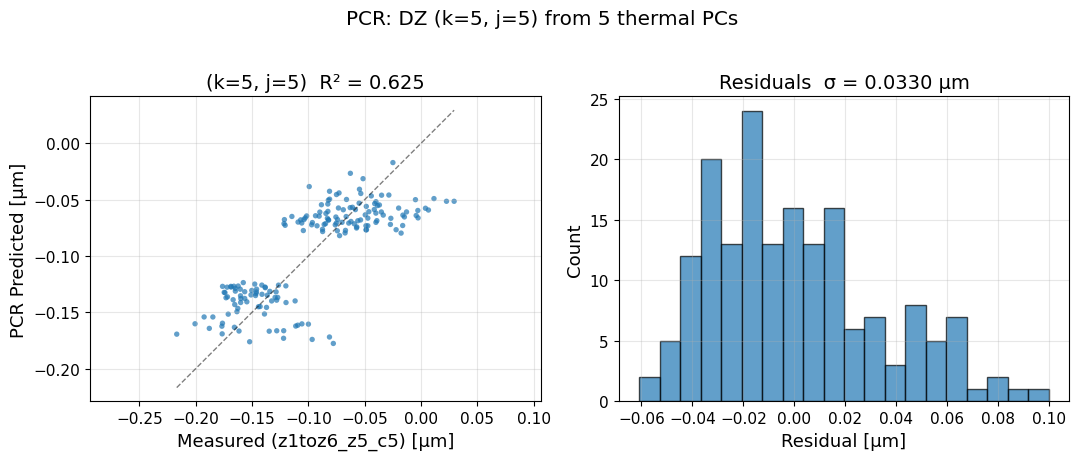

(k=6, j=6)  R² = 0.388  R²_adj = 0.370  (n=175)


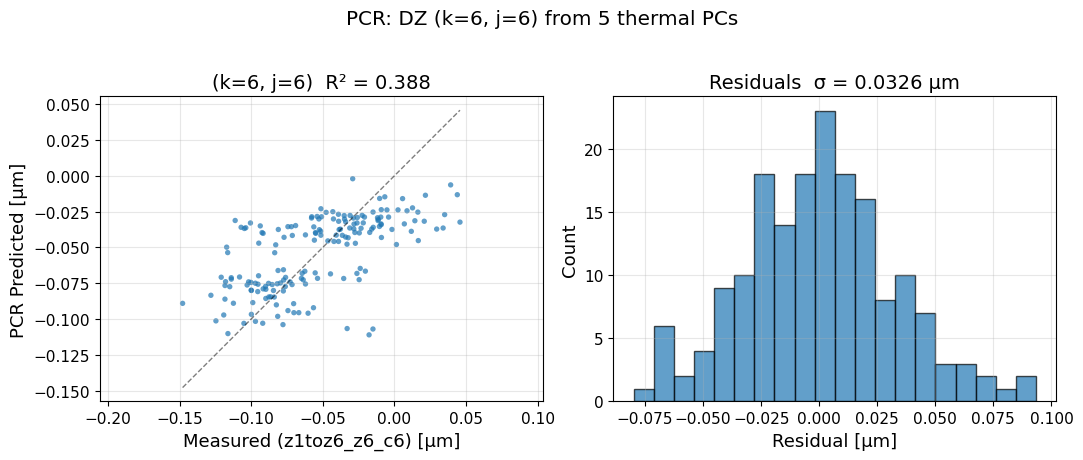

(k=4, j=4)  R² = 0.859  R²_adj = 0.855  (n=175)


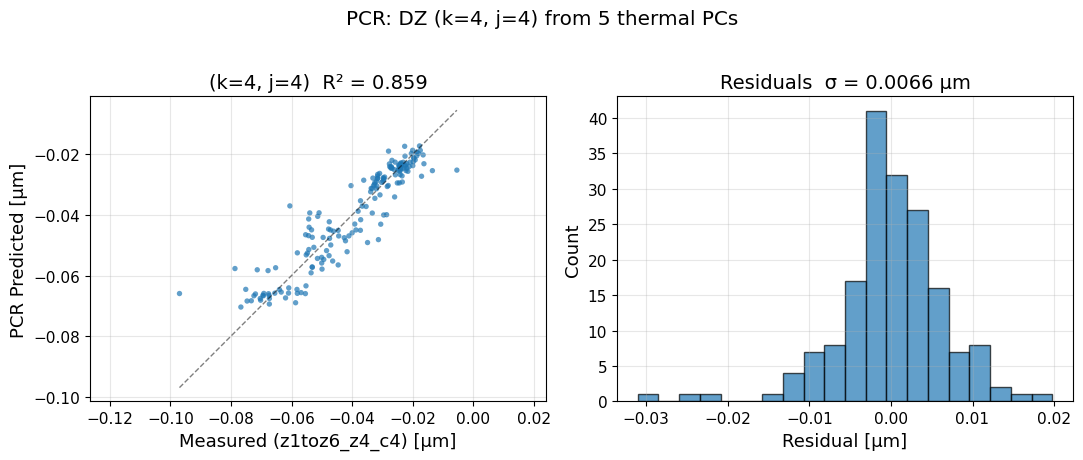

(k=5, j=10)  R² = 0.488  R²_adj = 0.473  (n=175)


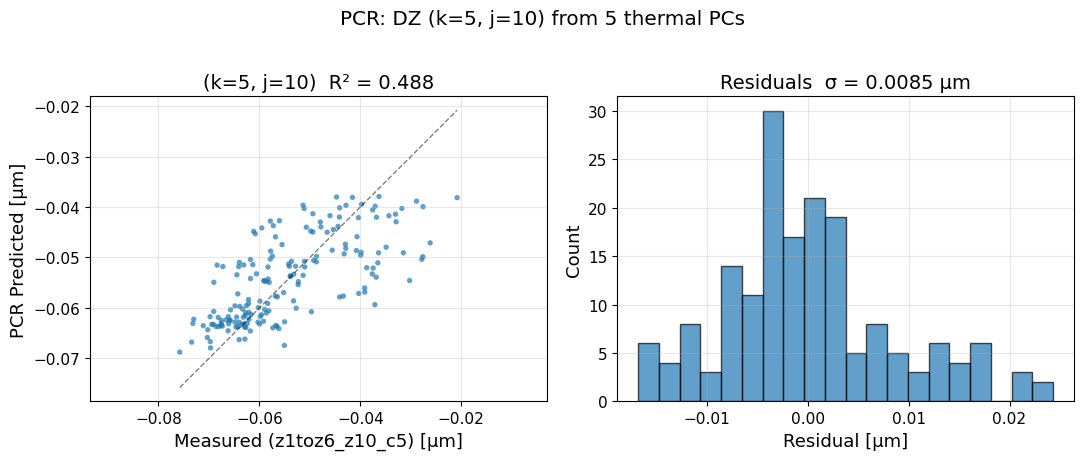

(k=6, j=9)  R² = 0.831  R²_adj = 0.826  (n=175)


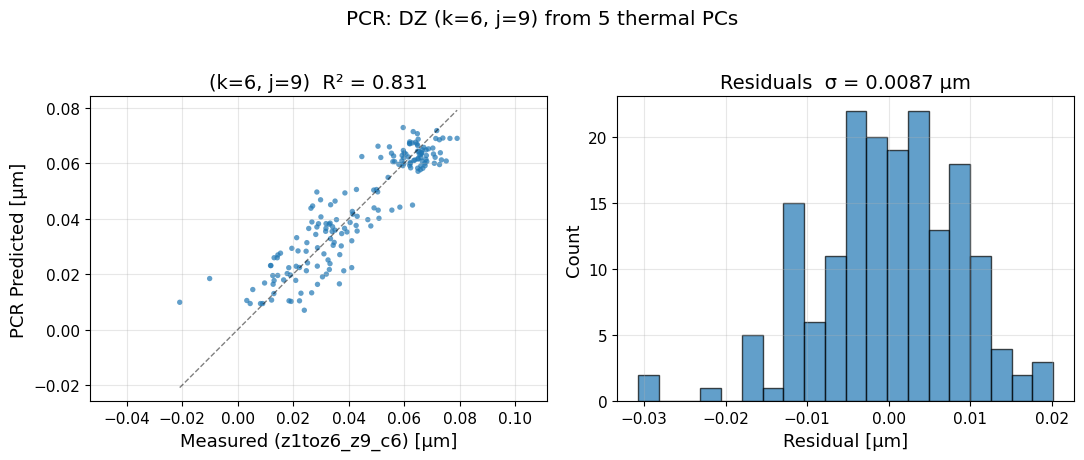

In [10]:
# Principal Component Regression for each DZ coefficient
# OLS: y = X @ beta, where X = PC scores (with intercept)

X = np.column_stack([np.ones(pc_scores.shape[0]), pc_scores])  # add intercept

pcr_results = []
pcr_figs = []

for k, j, dz_col in available_dz:
    y = df.loc[valid_mask, dz_col].values
    if np.all(np.isnan(y)):
        print(f"(k={k}, j={j}): all NaN, skipping")
        continue

    # Drop any remaining NaN in y
    y_mask = ~np.isnan(y)
    X_fit = X[y_mask]
    y_fit = y[y_mask]

    # OLS solution
    beta, residuals, rank, sv = np.linalg.lstsq(X_fit, y_fit, rcond=None)
    y_pred = X_fit @ beta
    ss_res = np.sum((y_fit - y_pred) ** 2)
    ss_tot = np.sum((y_fit - y_fit.mean()) ** 2)
    r_squared = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0

    # Adjusted R^2
    n = len(y_fit)
    p = X_fit.shape[1] - 1  # number of predictors (excluding intercept)
    r2_adj = 1.0 - (1.0 - r_squared) * (n - 1) / (n - p - 1) if n > p + 1 else r_squared

    pcr_results.append({
        'k': k, 'j': j, 'dz_col': dz_col,
        'R2': r_squared, 'R2_adj': r2_adj, 'n': n,
        'beta': beta,
    })

    print(f"(k={k}, j={j})  R\u00b2 = {r_squared:.3f}  R\u00b2_adj = {r2_adj:.3f}  (n={n})")

    # Plot: predicted vs actual, and residuals
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

    ax1.scatter(y_fit, y_pred, s=15, alpha=0.7, edgecolors='none')
    lims = [min(y_fit.min(), y_pred.min()), max(y_fit.max(), y_pred.max())]
    ax1.plot(lims, lims, 'k--', lw=1, alpha=0.5)
    ax1.set_xlabel(f'Measured ({dz_col}) [\u03bcm]')
    ax1.set_ylabel('PCR Predicted [\u03bcm]')
    ax1.set_title(f'(k={k}, j={j})  R\u00b2 = {r_squared:.3f}')
    ax1.set_aspect('equal', adjustable='datalim')

    resid = y_fit - y_pred
    ax2.hist(resid, bins=20, edgecolor='black', alpha=0.7)
    ax2.set_xlabel('Residual [\u03bcm]')
    ax2.set_ylabel('Count')
    ax2.set_title(f'Residuals  \u03c3 = {resid.std():.4f} \u03bcm')

    fig.suptitle(f'PCR: DZ (k={k}, j={j}) from {pca.n_components_} thermal PCs', y=1.02)
    fig.tight_layout()
    pcr_figs.append(fig)
    plt.show()

In [11]:
# Summary table and per-PC contribution
print("PCR Summary")
print("=" * 70)
print(f"{'DZ term':<15} {'R\u00b2':>8} {'R\u00b2_adj':>8} {'n':>5}  Top PC contributions")
print("-" * 70)

for res in pcr_results:
    # beta[0] is intercept, beta[1:] are PC coefficients
    pc_betas = res['beta'][1:]
    # Rank PCs by |beta * std(PC)| ~ contribution to variance
    pc_std = pc_scores[:, :len(pc_betas)].std(axis=0)
    contributions = np.abs(pc_betas) * pc_std
    top_pcs = np.argsort(contributions)[::-1][:3]
    top_str = ', '.join(
        f'PC{i+1}({contributions[i]:.4f})' for i in top_pcs
    )
    print(f"({res['k']:>2},{res['j']:>2})        {res['R2']:>8.3f} {res['R2_adj']:>8.3f} {res['n']:>5}  {top_str}")

PCR Summary
DZ term               R²   R²_adj     n  Top PC contributions
----------------------------------------------------------------------
( 5, 5)           0.625    0.613   175  PC1(0.0322), PC2(0.0226), PC3(0.0135)
( 6, 6)           0.388    0.370   175  PC1(0.0207), PC2(0.0093), PC3(0.0081)
( 4, 4)           0.859    0.855   175  PC1(0.0115), PC2(0.0098), PC5(0.0052)
( 5,10)           0.488    0.473   175  PC1(0.0067), PC5(0.0037), PC3(0.0024)
( 6, 9)           0.831    0.826   175  PC1(0.0158), PC2(0.0085), PC5(0.0064)


/tmp/ipykernel_1860/113935195.py:20: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


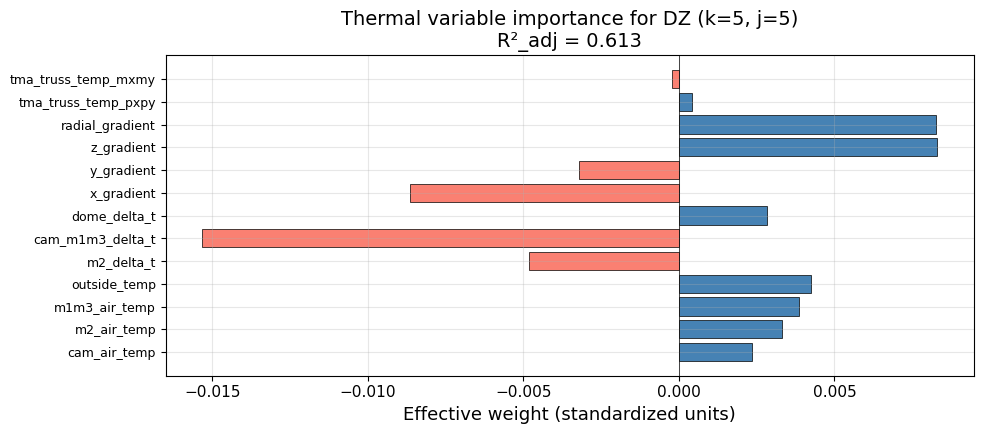

/tmp/ipykernel_1860/113935195.py:20: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


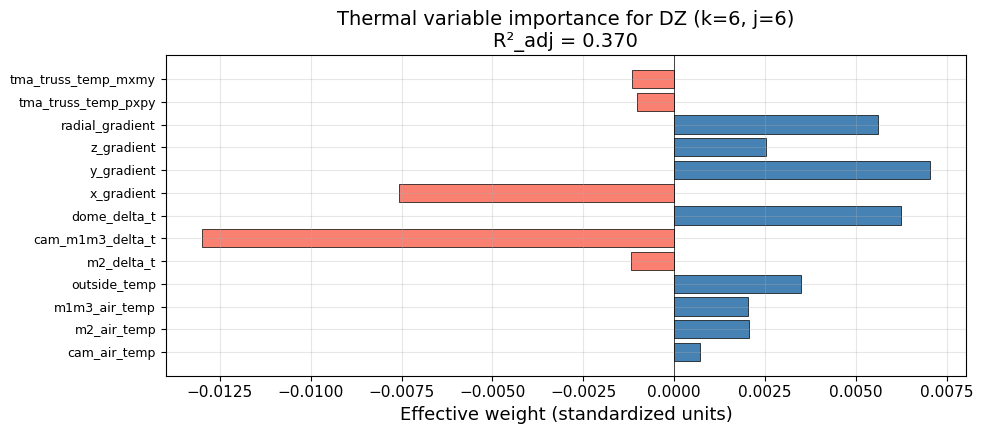

/tmp/ipykernel_1860/113935195.py:20: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


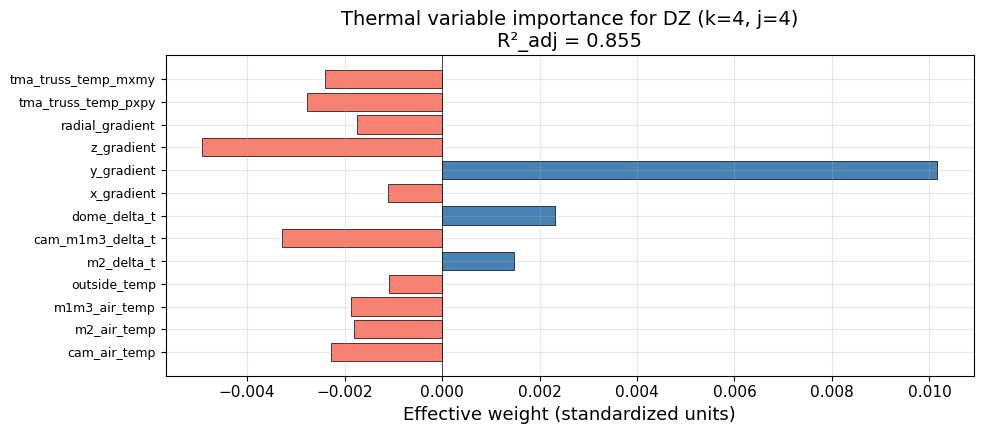

/tmp/ipykernel_1860/113935195.py:20: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


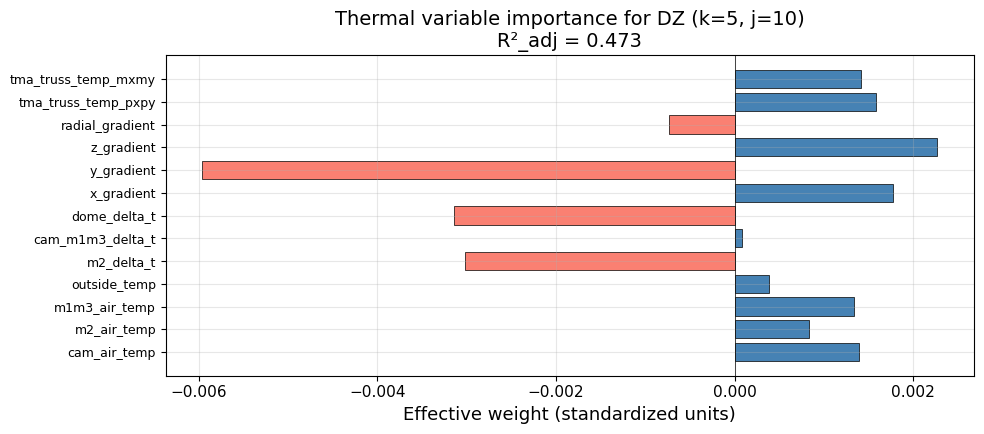

/tmp/ipykernel_1860/113935195.py:20: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


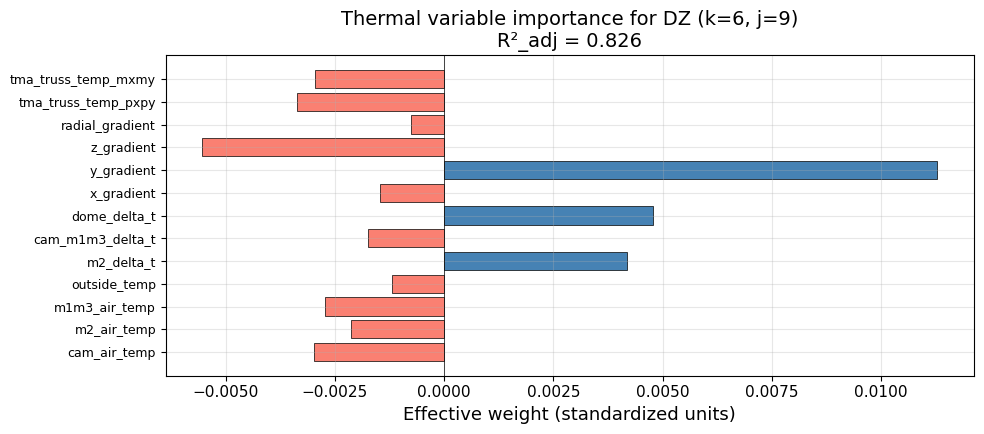

In [12]:
# Map PC regression back to original thermal variables
# For each DZ term, compute the effective weight of each original thermal variable
# weight_j = sum_i (beta_i * loading_ij)  (in standardized space)

importance_figs = []
for res in pcr_results:
    pc_betas = res['beta'][1:]  # exclude intercept
    # loadings: (n_components, n_thermal) -> components_ rows are PCs
    thermal_weights = pca.components_[:len(pc_betas)].T @ pc_betas  # (n_thermal,)

    fig, ax = plt.subplots(figsize=(10, 4.5))
    colors = ['steelblue' if w >= 0 else 'salmon' for w in thermal_weights]
    ax.barh(range(len(thermal_vars)), thermal_weights, color=colors, edgecolor='black', lw=0.5)
    ax.set_yticks(range(len(thermal_vars)))
    ax.set_yticklabels(thermal_vars, fontsize=9)
    ax.set_xlabel('Effective weight (standardized units)')
    ax.set_title(f'Thermal variable importance for DZ (k={res["k"]}, j={res["j"]})\n'
                 f'R\u00b2_adj = {res["R2_adj"]:.3f}')
    ax.axvline(0, color='black', lw=0.5)
    fig.tight_layout()
    importance_figs.append(fig)
    plt.show()

<a id='output'></a>
## Output

Combine all figures into a single PDF.

In [13]:
os.makedirs(output_dir, exist_ok=True)

with PdfPages(output_pdf) as pdf:
    # Scatter plot pages
    for fig in scatter_figs:
        pdf.savefig(fig, bbox_inches='tight')

    # PCA loadings
    pdf.savefig(fig_loadings, bbox_inches='tight')

    # PCR predicted vs actual + residuals
    for fig in pcr_figs:
        pdf.savefig(fig, bbox_inches='tight')

    # Thermal importance bar charts
    for fig in importance_figs:
        pdf.savefig(fig, bbox_inches='tight')

print(f"Saved {len(scatter_figs) + 1 + len(pcr_figs) + len(importance_figs)} pages to {output_pdf}")

Saved 16 pages to output/fam_danish_bin1_OCS_wep_v16_8_0_dviz_v3_5_0_20260315_20260317/intrinsics_thermal_correlations.pdf
